In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

file_path = '/content/AMS_PVD_final_dataset.xlsx'

df = pd.read_excel(file_path)

print(df.head())
print(df.shape)
print(df.info())

   Number     Stardate      Enddate  Peakvalue  Volume  Duration
0       1  01-Apr-1975  03-Apr-1975     9499.4   95194         3
1       2  05-Jan-1976  17-Jan-1976     8953.9  182910        13
2       3  24-Jan-1977  29-Jan-1977     6891.2  111210         6
3       4  30-Mar-1978  02-Apr-1978    17442.0  317670         4
4       5  11-Mar-1979  17-Mar-1979    20796.0  508060         7
(46, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46 entries, 0 to 45
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Number     46 non-null     int64  
 1   Stardate   46 non-null     object 
 2   Enddate    46 non-null     object 
 3   Peakvalue  46 non-null     float64
 4   Volume     46 non-null     int64  
 5   Duration   46 non-null     int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 2.3+ KB
None


In [ ]:
df[["Peakvalue", "Volume", "Duration"]].describe()
df[["Peakvalue", "Volume", "Duration"]].skew()


,0
Peakvalue,1.492359
Volume,3.136009
Duration,0.382033


In [ ]:
cv = (
    df[["Peakvalue", "Volume", "Duration"]].std()
    / df[["Peakvalue", "Volume", "Duration"]].mean()
)

print(cv)

Peakvalue    0.642643
Volume       0.815769
Duration     0.326557
dtype: float64


In [ ]:
corr_pearson = df[["Peakvalue", "Volume", "Duration"]].corr(
    method="pearson"
)

print(corr_pearson)

           Peakvalue    Volume  Duration
Peakvalue   1.000000  0.907716  0.130636
Volume      0.907716  1.000000  0.332004
Duration    0.130636  0.332004  1.000000


In [ ]:
corr_spearman = df[["Peakvalue", "Volume", "Duration"]].corr(
    method="spearman"
)

print(corr_spearman)

           Peakvalue    Volume  Duration
Peakvalue   1.000000  0.868023  0.062868
Volume      0.868023  1.000000  0.290427
Duration    0.062868  0.290427  1.000000


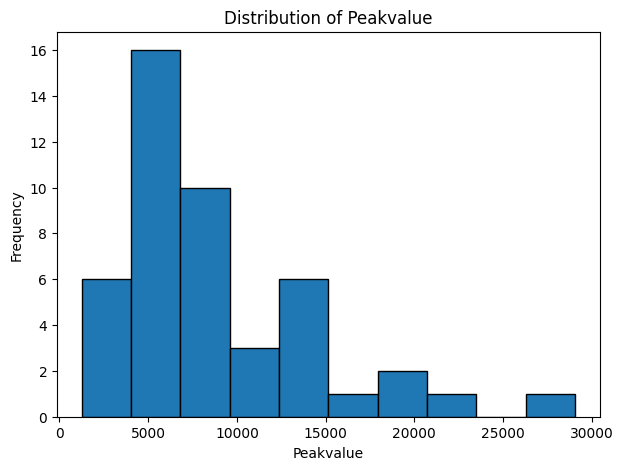

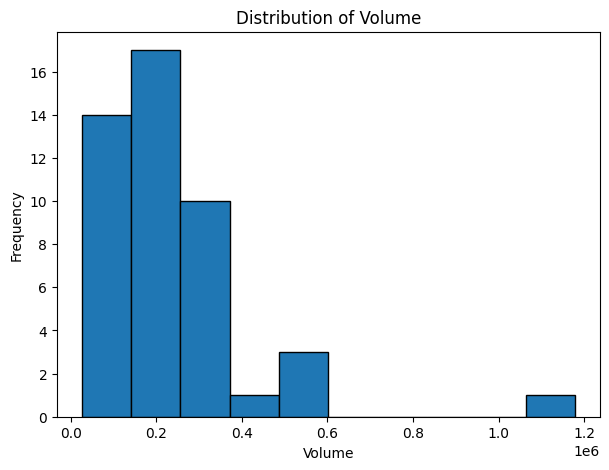

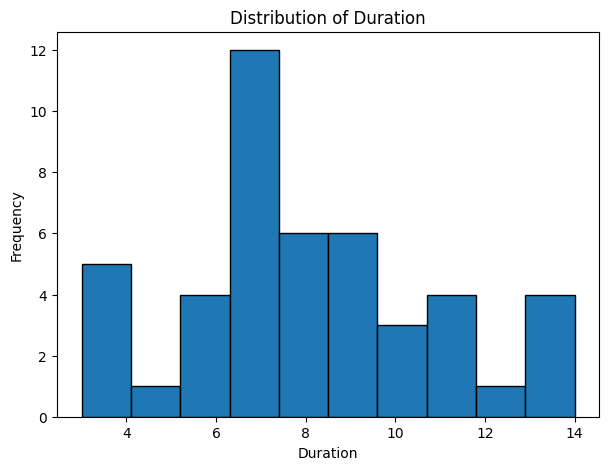

In [ ]:
variables = ["Peakvalue", "Volume", "Duration"]

for col in variables:
    plt.figure(figsize=(7,5))
    plt.hist(df[col], bins=10, edgecolor="black")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {col}")
    plt.show()

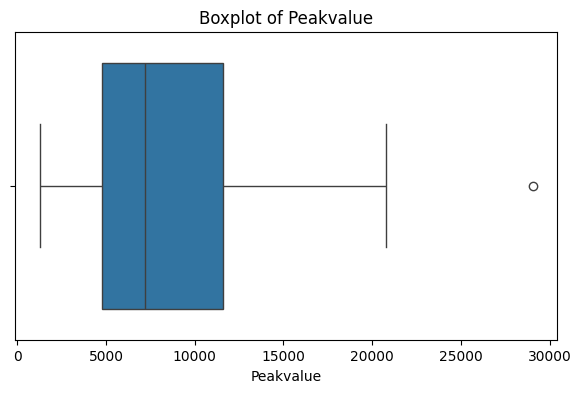

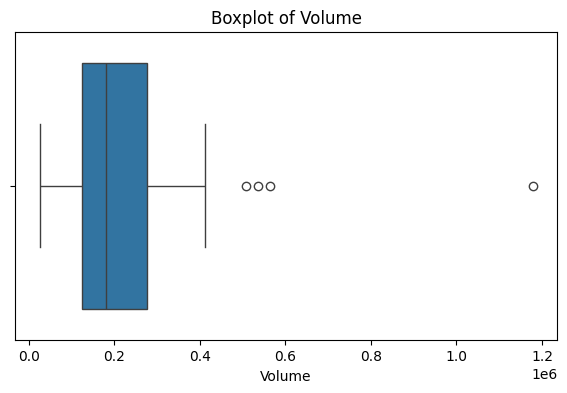

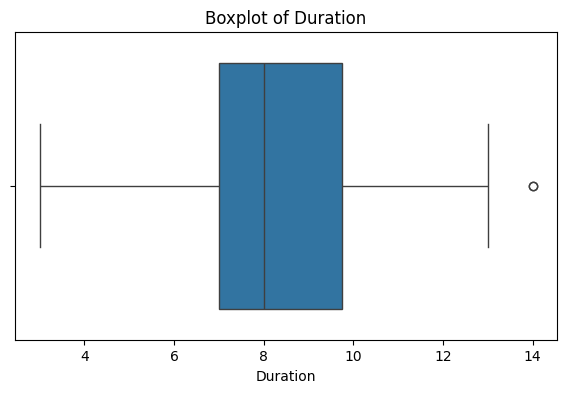

In [ ]:
for col in variables:
    plt.figure(figsize=(7,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

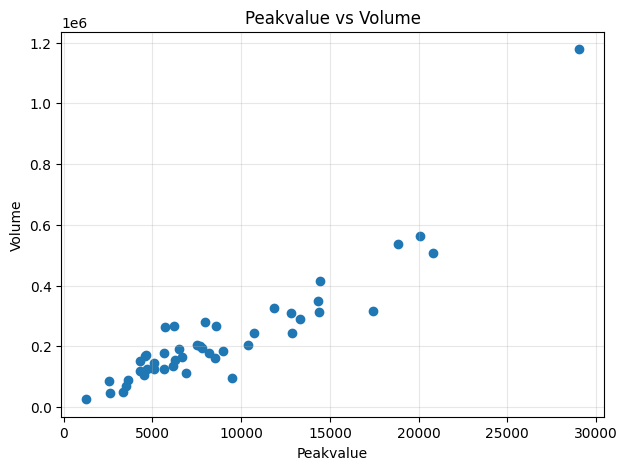

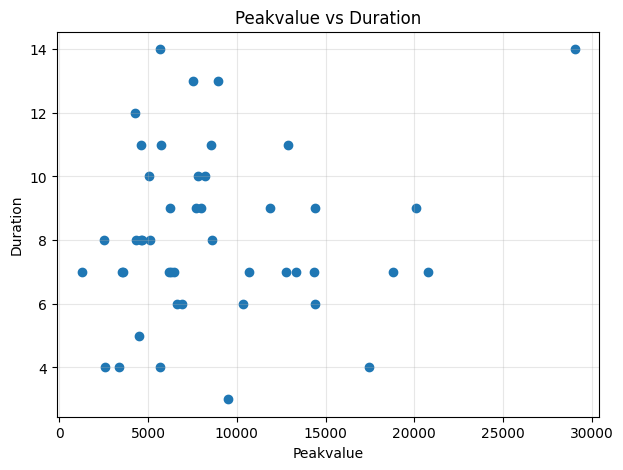

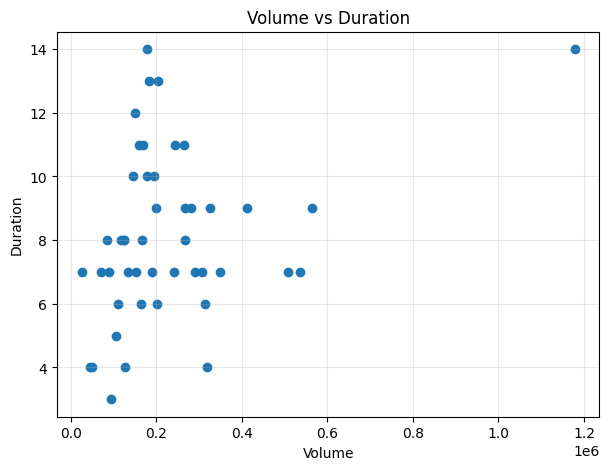

In [ ]:
pairs = [
    ("Peakvalue", "Volume"),
    ("Peakvalue", "Duration"),
    ("Volume", "Duration")
]

for x, y in pairs:
    plt.figure(figsize=(7,5))
    plt.scatter(df[x], df[y])
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(f"{x} vs {y}")
    plt.grid(True, alpha=0.3)
    plt.show()

In [ ]:
from scipy.stats import rankdata

n = len(df)

U_peak = rankdata(df["Peakvalue"]) / (n + 1)
U_volume = rankdata(df["Volume"]) / (n + 1)
U_duration = rankdata(df["Duration"]) / (n + 1)

In [ ]:
U = pd.DataFrame({
    "Peak": U_peak,
    "Volume": U_volume,
    "Duration": U_duration
})

U.head()

,Peak,Volume,Duration
0,0.680851,0.148936,0.021277
1,0.659574,0.510638,0.925532
2,0.489362,0.191489,0.180851
3,0.893617,0.829787,0.074468
4,0.957447,0.914894,0.351064


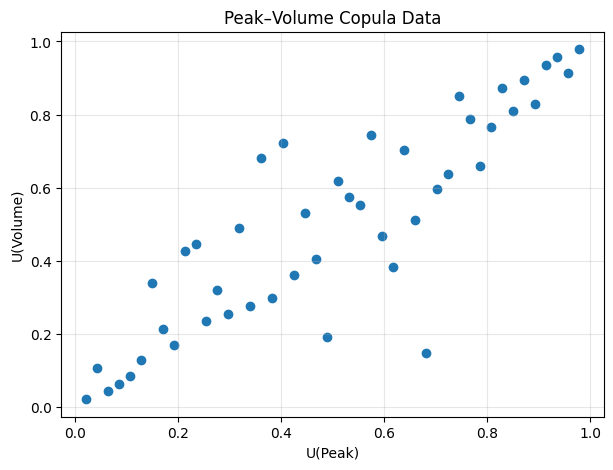

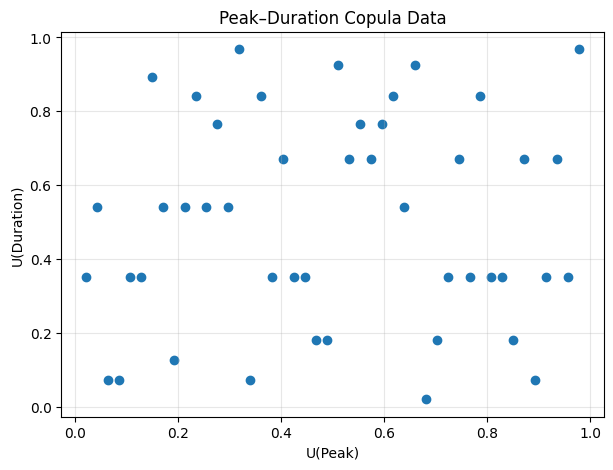

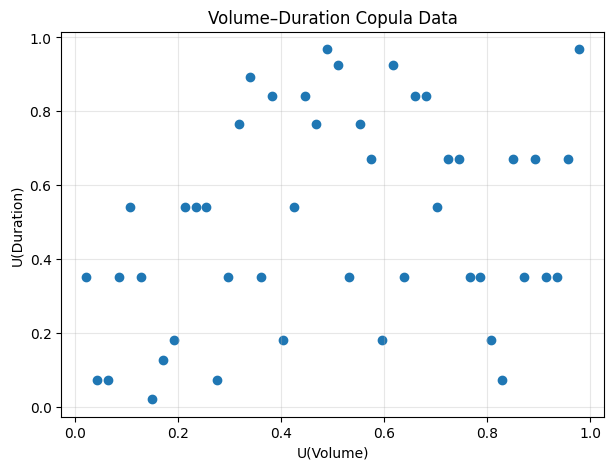

In [ ]:
plt.figure(figsize=(7,5))

plt.scatter(U["Peak"], U["Volume"])

plt.xlabel("U(Peak)")
plt.ylabel("U(Volume)")
plt.title("Peak–Volume Copula Data")
plt.grid(True, alpha=0.3)

plt.show()
plt.figure(figsize=(7,5))

plt.scatter(U["Peak"], U["Duration"])

plt.xlabel("U(Peak)")
plt.ylabel("U(Duration)")
plt.title("Peak–Duration Copula Data")
plt.grid(True, alpha=0.3)

plt.show()
plt.figure(figsize=(7,5))

plt.scatter(U["Volume"], U["Duration"])

plt.xlabel("U(Volume)")
plt.ylabel("U(Duration)")
plt.title("Volume–Duration Copula Data")
plt.grid(True, alpha=0.3)

plt.show()

In [ ]:
from scipy import stats
distributions = {

    "Lognormal": stats.lognorm,

    "Gamma": stats.gamma,

    "Weibull": stats.weibull_min,

    "Gumbel": stats.gumbel_r,

    "GEV": stats.genextreme
}

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats


# ============================================================
# MARGINAL DISTRIBUTION FITTING
# AIC/BIC selection + Anderson-Darling validation
# ============================================================

def fit_marginal_distribution(data, distributions, alpha=0.05):

    data = np.asarray(data, dtype=float)
    data = data[np.isfinite(data)]

    results = []

    n = len(data)

    for name, dist in distributions.items():

        try:
            # ------------------------------------------------
            # 1. Fit distribution
            # ------------------------------------------------
            params = dist.fit(data)

            # ------------------------------------------------
            # 2. Log-likelihood
            # ------------------------------------------------
            logpdf = dist.logpdf(data, *params)

            # Check for invalid likelihood
            if not np.all(np.isfinite(logpdf)):
                raise ValueError("Invalid log-likelihood")

            loglik = np.sum(logpdf)

            # Number of fitted parameters
            k = len(params)

            # ------------------------------------------------
            # 3. AIC
            # ------------------------------------------------
            aic = 2 * k - 2 * loglik

            # ------------------------------------------------
            # 4. BIC
            # ------------------------------------------------
            bic = k * np.log(n) - 2 * loglik

            # ------------------------------------------------
            # 5. Anderson-Darling test
            # ------------------------------------------------
            #
            # scipy's anderson() does NOT directly support
            # arbitrary fitted distributions.
            #
            # Therefore use the probability-integral
            # transformation:
            #
            # U = F(X)
            #
            # and calculate the AD statistic for U ~ Uniform(0,1)
            # ------------------------------------------------

            cdf_values = dist.cdf(data, *params)

            # Avoid exactly 0 and 1
            cdf_values = np.clip(
                cdf_values,
                1e-10,
                1 - 1e-10
            )

            # Sort the transformed observations
            u = np.sort(cdf_values)

            i = np.arange(1, n + 1)

            ad_stat = -n - np.sum(
                (2 * i - 1) / n *
                (
                    np.log(u) +
                    np.log(1 - u[::-1])
                )
            )

            results.append({
                "Distribution": name,
                "LogLikelihood": loglik,
                "AIC": aic,
                "BIC": bic,
                "AD_Statistic": ad_stat,
                "Parameters": params
            })

        except Exception:

            results.append({
                "Distribution": name,
                "LogLikelihood": np.nan,
                "AIC": np.nan,
                "BIC": np.nan,
                "AD_Statistic": np.nan,
                "Parameters": None
            })


    results_df = pd.DataFrame(results)


    # ========================================================
    # AIC AND BIC RANKING
    # ========================================================

    results_df["AIC_Rank"] = (
        results_df["AIC"]
        .rank(method="min")
    )

    results_df["BIC_Rank"] = (
        results_df["BIC"]
        .rank(method="min")
    )


    # ========================================================
    # COMBINED AIC/BIC RANK
    #
    # Lower is better.
    # ========================================================

    results_df["Mean_Rank"] = (
        results_df["AIC_Rank"] +
        results_df["BIC_Rank"]
    ) / 2


    # ========================================================
    # ORDER DISTRIBUTIONS
    # ========================================================

    ranked_results = results_df.sort_values(
        by=["Mean_Rank", "AIC", "BIC"]
    ).reset_index(drop=True)


    # ========================================================
    # AD VALIDATION
    #
    # AD critical value at 5% significance level
    # for the uniform-transformed statistic is approximately
    # 2.492.
    #
    # H0: Data follow the fitted distribution
    #
    # AD <= critical value -> PASS
    # AD > critical value  -> FAIL
    # ========================================================

    AD_CRITICAL_5 = 2.492

    ranked_results["AD_Pass_5pct"] = (
        ranked_results["AD_Statistic"] <= AD_CRITICAL_5
    )


    # ========================================================
    # SELECT DISTRIBUTION
    #
    # Start with best AIC/BIC candidate.
    # If it fails AD, move to next candidate.
    # ========================================================

    selected = None

    for _, row in ranked_results.iterrows():

        if (
            np.isfinite(row["AD_Statistic"])
            and row["AD_Pass_5pct"]
        ):
            selected = row
            break


    # --------------------------------------------------------
    # If no candidate passes AD
    # --------------------------------------------------------

    if selected is None:

        print(
            "WARNING: No fitted distribution passed "
            "the AD test at 5% significance."
        )

        # In this case retain the best AIC/BIC candidate
        selected = ranked_results.iloc[0]


    selected_distribution = selected["Distribution"]
    selected_parameters = selected["Parameters"]

    selected_dist = distributions[selected_distribution]


    return (
        ranked_results,
        selected_distribution,
        selected_parameters,
        selected_dist
    )

In [ ]:
peak_results, peak_name, peak_params, peak_dist = fit_marginal_distribution(
    df["Peakvalue"].values, distributions
)

volume_results, volume_name, volume_params, volume_dist = fit_marginal_distribution(
    df["Volume"].values, distributions
)

duration_results, duration_name, duration_params, duration_dist = fit_marginal_distribution(
    df["Duration"].values, distributions
)

In [ ]:
print("\nPEAK")
display(peak_results)

print("\nSelected:", peak_dist)
print("Parameters:", peak_params)


print("\nVOLUME")
display(volume_results)

print("\nSelected:", volume_dist)
print("Parameters:", volume_params)


print("\nDURATION")
display(duration_results)

print("\nSelected:", duration_dist)
print("Parameters:", duration_params)


PEAK


,Distribution,LogLikelihood,AIC,BIC,AD_Statistic,Parameters,AIC_Rank,BIC_Rank,Mean_Rank,AD_Pass_5pct
0,Lognormal,-452.508004,911.016009,916.501933,0.190302,"(0.5643812048512881, -585.3942874542497, 8024....",1.0,2.0,1.5,True
1,Gumbel,-454.068728,912.137455,915.794738,0.543748,"(6429.762795246157, 3795.8908673330534)",3.0,1.0,2.0,True
2,Gamma,-452.824751,911.649502,917.135426,0.302012,"(2.1985951967133883, 808.5771496561348, 3643.3...",2.0,3.0,2.5,True
3,GEV,-544.421895,1094.843790,1100.329715,26.773552,"(-7.431060250457115, 1251.538805986946, 3.2607...",4.0,4.0,4.0,False
4,Weibull,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,False



Selected: <scipy.stats._continuous_distns.lognorm_gen object at 0x7f1db275ee40>
Parameters: (np.float64(0.5643812048512881), -585.3942874542497, np.float64(8024.20082117337))

VOLUME


,Distribution,LogLikelihood,AIC,BIC,AD_Statistic,Parameters,AIC_Rank,BIC_Rank,Mean_Rank,AD_Pass_5pct
0,Lognormal,-604.993391,1215.986782,1221.472706,0.267137,"(0.6015008685714114, -19705.01142811144, 20719...",1.0,1.0,1.0,True
1,Gumbel,-607.645057,1219.290114,1222.947397,0.497764,"(162753.30798216208, 104807.98705479798)",2.0,2.0,2.0,True
2,GEV,-795.530742,1597.061483,1602.547407,151.748014,"(-3.229605010477507, 25540.054783217434, 0.178...",3.0,3.0,3.0,False
3,Gamma,-294087.630788,588181.261576,588186.747501,977.823701,"(0.00021770316403016778, 25539.999999999956, 3...",4.0,4.0,4.0,False
4,Weibull,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,False



Selected: <scipy.stats._continuous_distns.lognorm_gen object at 0x7f1db275ee40>
Parameters: (np.float64(0.6015008685714114), -19705.01142811144, np.float64(207195.69327045424))

DURATION


,Distribution,LogLikelihood,AIC,BIC,AD_Statistic,Parameters,AIC_Rank,BIC_Rank,Mean_Rank,AD_Pass_5pct
0,Weibull,-108.779820,223.559639,229.045563,0.694635,"(2.430140762579083, 2.132765791387442, 6.75964...",1.0,2.0,1.5,True
1,GEV,-108.888231,223.776462,229.262386,0.660772,"(0.17916196306234766, 7.090828280757718, 2.430...",2.0,3.0,2.5,True
2,Gumbel,-110.065661,224.131321,227.788604,0.808765,"(6.863473972264104, 2.345839361527276)",5.0,1.0,3.0,True
3,Gamma,-109.002458,224.004916,229.490840,0.651950,"(18.628286589684535, -3.241589102784664, 0.610...",3.0,4.0,3.5,True
4,Lognormal,-109.031187,224.062375,229.548299,0.648376,"(0.15118308268789962, -9.191659901364075, 17.1...",4.0,5.0,4.5,True



Selected: <scipy.stats._continuous_distns.weibull_min_gen object at 0x7f1db2673cb0>
Parameters: (np.float64(2.430140762579083), np.float64(2.132765791387442), np.float64(6.759642089615893))


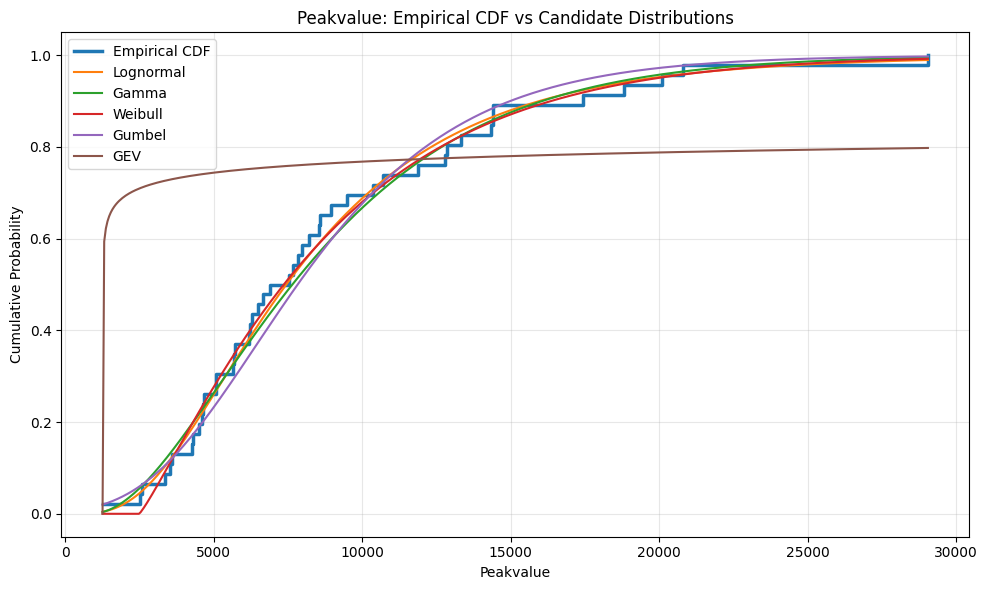

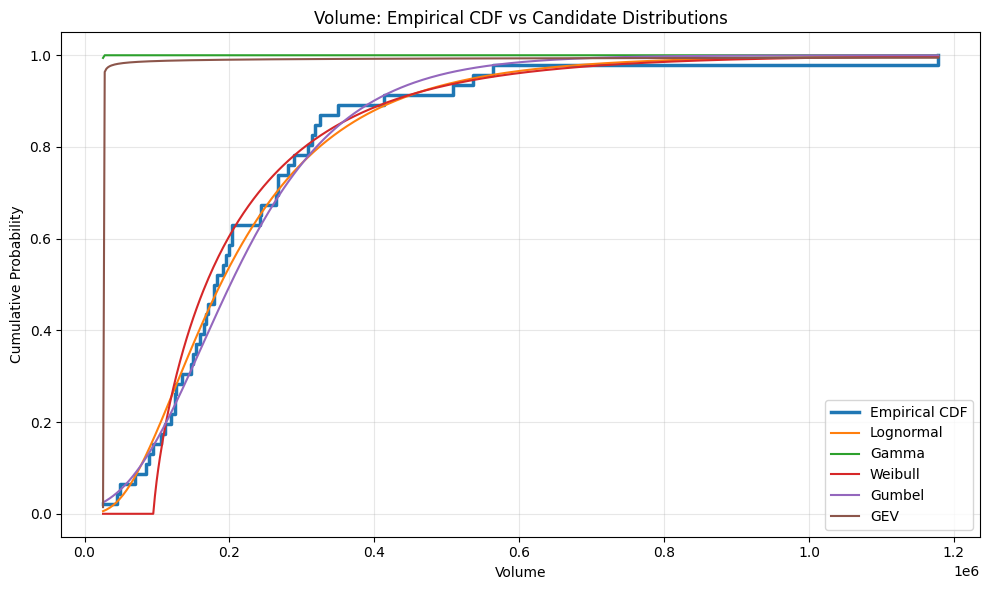

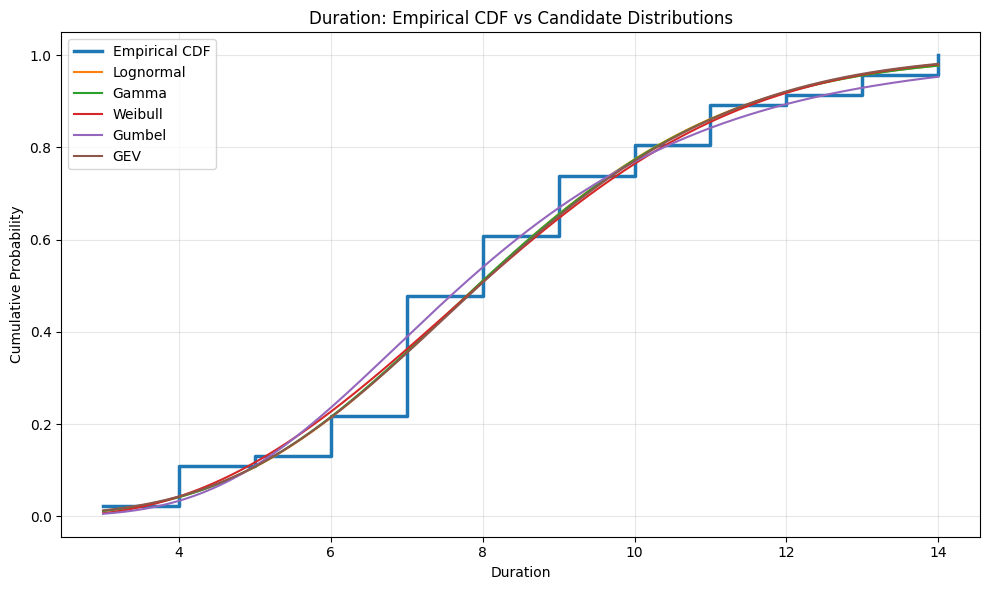

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# =========================================================
# Load P-V-D data
# =========================================================

df = pd.read_excel("/content/AMS_PVD_final_dataset.xlsx")

peak = df["Peakvalue"].dropna().values
volume = df["Volume"].dropna().values
duration = df["Duration"].dropna().values


# =========================================================
# Candidate distributions
# =========================================================

distributions = {
    "Lognormal": stats.lognorm,
    "Gamma": stats.gamma,
    "Weibull": stats.weibull_min,
    "Gumbel": stats.gumbel_r,
    "GEV": stats.genextreme
}


# =========================================================
# Function to plot empirical CDF + fitted distributions
# =========================================================

def plot_cdf_comparison(data, variable_name):

    # Sort data for empirical CDF
    x_emp = np.sort(data)

    # Empirical CDF
    y_emp = np.arange(1, len(data) + 1) / len(data)

    # Smooth x-axis for fitted distributions
    x_fit = np.linspace(
        np.min(data),
        np.max(data),
        500
    )

    plt.figure(figsize=(10, 6))

    # Empirical CDF
    plt.step(
        x_emp,
        y_emp,
        where="post",
        linewidth=2.5,
        label="Empirical CDF"
    )

    # Fit and plot each candidate distribution
    for name, dist in distributions.items():

        try:

            # Estimate distribution parameters
            params = dist.fit(data)

            # Calculate fitted CDF
            y_fit = dist.cdf(
                x_fit,
                *params
            )

            # Avoid plotting invalid results
            if np.all(np.isfinite(y_fit)):

                plt.plot(
                    x_fit,
                    y_fit,
                    linewidth=1.5,
                    label=name
                )

        except Exception as e:

            print(
                f"{name} could not be fitted "
                f"for {variable_name}: {e}"
            )

    plt.xlabel(variable_name)
    plt.ylabel("Cumulative Probability")

    plt.title(
        f"{variable_name}: Empirical CDF vs Candidate Distributions"
    )

    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


# =========================================================
# Generate plots
# =========================================================

plot_cdf_comparison(
    peak,
    "Peakvalue"
)

plot_cdf_comparison(
    volume,
    "Volume"
)

plot_cdf_comparison(
    duration,
    "Duration"
)

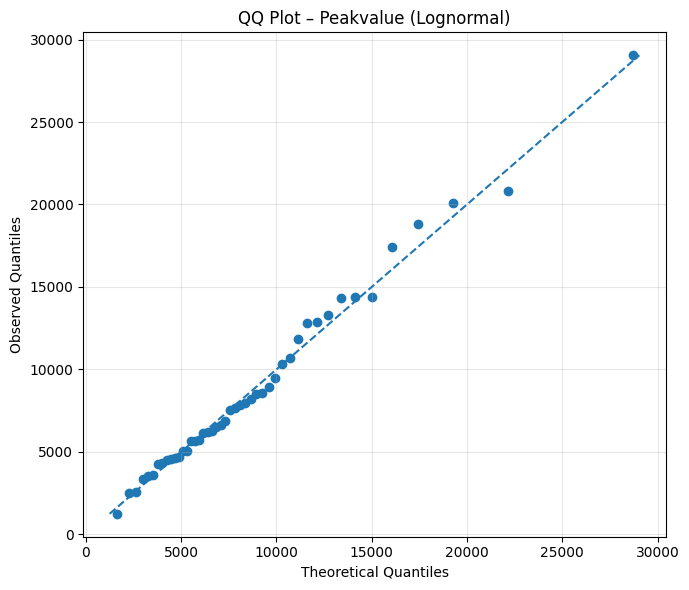

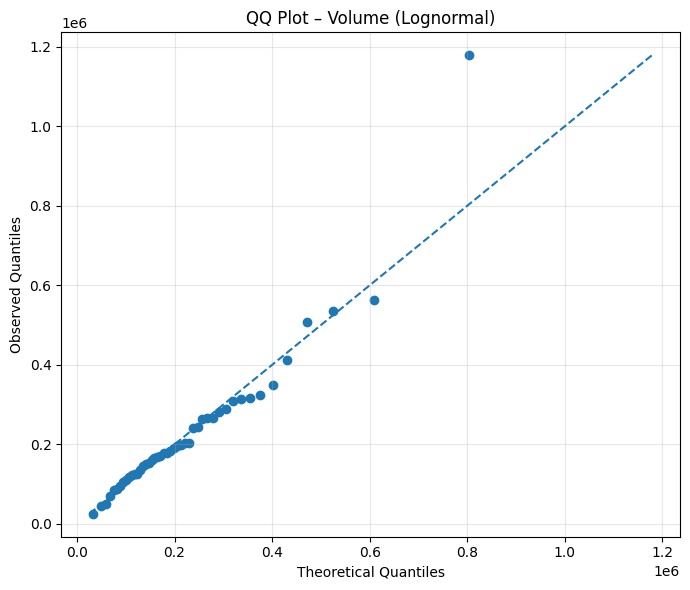

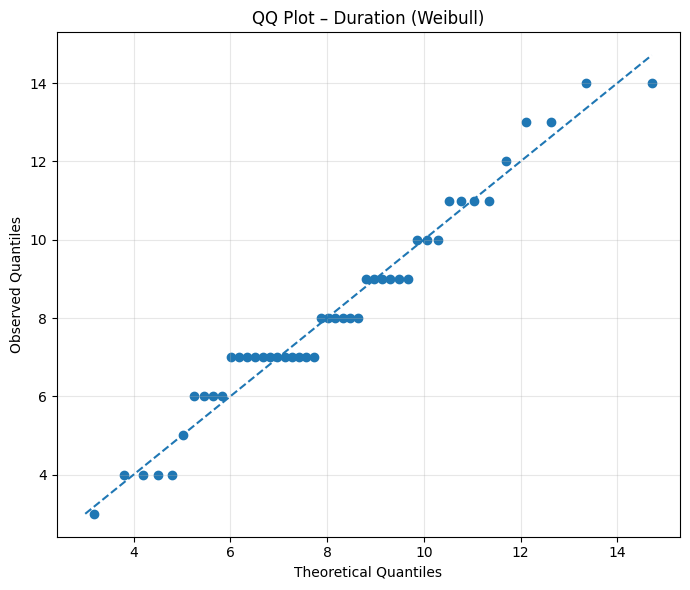

In [ ]:
# =========================
# QQ PLOTS
# =========================

def qq_plot(data, distribution, params, title):

    data = np.sort(data)
    n = len(data)

    # Empirical probabilities
    p = (np.arange(1, n + 1) - 0.5) / n

    # Theoretical quantiles
    theoretical = distribution.ppf(p, *params)

    plt.figure(figsize=(7, 6))

    plt.scatter(theoretical, data)

    # 45-degree reference line
    mn = min(theoretical.min(), data.min())
    mx = max(theoretical.max(), data.max())

    plt.plot([mn, mx], [mn, mx], '--')

    plt.xlabel("Theoretical Quantiles")
    plt.ylabel("Observed Quantiles")
    plt.title(title)

    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# Peakvalue → Lognormal
qq_plot(
    df["Peakvalue"].dropna().values,
    stats.lognorm,
    peak_params,
    "QQ Plot – Peakvalue (Lognormal)"
)

# Volume → Weibull
qq_plot(
    df["Volume"].dropna().values,
    stats.lognorm,
    volume_params,
    "QQ Plot – Volume (Lognormal)"
)

# Duration → Weibull
qq_plot(
    df["Duration"].dropna().values,
    stats.weibull_min,
    duration_params,
    "QQ Plot – Duration (Weibull)"
)

In [ ]:
# ============================================
# FITTED MARGINAL CDF VALUES
# Automatic based on selected distributions
# ============================================

peak = df["Peakvalue"].values
volume = df["Volume"].values
duration = df["Duration"].values


# ------------------------------------------------
# Calculate CDF using automatically selected
# marginal distributions and their fitted parameters
# ------------------------------------------------

u = peak_dist.cdf(peak, *peak_params)
v = volume_dist.cdf(volume, *volume_params)
w = duration_dist.cdf(duration, *duration_params)


# ------------------------------------------------
# Create dataframe of transformed variables
# ------------------------------------------------

cdf_df = pd.DataFrame({
    "Peakvalue": peak,
    "Volume": volume,
    "Duration": duration,
    "U_Peak": u,
    "U_Volume": v,
    "U_Duration": w
})


# ------------------------------------------------
# Display selected distributions
# ------------------------------------------------

print("\nSelected marginal distributions:")
print("Peak     :", peak_name)
print("Volume   :", volume_name)
print("Duration :", duration_name)


# ------------------------------------------------
# Display transformed dataset
# ------------------------------------------------

print("\nFitted marginal CDF values:")
print(cdf_df)


Selected marginal distributions:
Peak     : Lognormal
Volume   : Lognormal
Duration : Weibull

Fitted marginal CDF values:
    Peakvalue   Volume  Duration    U_Peak  U_Volume  U_Duration
0      9499.4    95194         3  0.657256  0.163486    0.006782
1      8953.9   182910        13  0.620371  0.485176    0.958004
2      6891.2   111210         6  0.450166  0.222647    0.226953
3     17442.0   317670         4  0.924241  0.791181    0.042927
4     20796.0   508060         7  0.958764  0.939958    0.362470
5      4622.9   170020        11  0.221894  0.441784    0.855412
6     10695.0   242180         7  0.726912  0.651521    0.362470
7      3349.4    49002         4  0.103361  0.033246    0.042927
8      6214.7   267620         9  0.384651  0.706627    0.646235
9      7816.6   195560        10  0.532485  0.525323    0.764469
10     2523.5    84754         8  0.046473  0.127435    0.507803
11     6488.5   191210         7  0.411634  0.511798    0.362470
12     2580.2    44945         

In [ ]:
print(type(peak_dist))
print(type(volume_dist))
print(type(duration_dist))

print(peak_dist)
print(volume_dist)
print(duration_dist)

<class 'scipy.stats._continuous_distns.lognorm_gen'>
<class 'scipy.stats._continuous_distns.lognorm_gen'>
<class 'scipy.stats._continuous_distns.weibull_min_gen'>


In [ ]:
import importlib.util

print("copulas:", importlib.util.find_spec("copulas"))
print("statsmodels:", importlib.util.find_spec("statsmodels"))

copulas: None
statsmodels: ModuleSpec(name='statsmodels', loader=<_frozen_importlib_external.SourceFileLoader object at 0x7f1db1c05a30>, origin='/usr/local/lib/python3.13/dist-packages/statsmodels/__init__.py', submodule_search_locations=['/usr/local/lib/python3.13/dist-packages/statsmodels'])


In [ ]:
# ============================================
# BIVARIATE COPULA DATASETS
# ============================================

PV = cdf_df[["U_Peak", "U_Volume"]]
PD = cdf_df[["U_Peak", "U_Duration"]]
VD = cdf_df[["U_Volume", "U_Duration"]]

print("\nPeak–Volume:")
print(PV)

print("\nPeak–Duration:")
print(PD)

print("\nVolume–Duration:")
print(VD)


Peak–Volume:
      U_Peak  U_Volume
0   0.657256  0.163486
1   0.620371  0.485176
2   0.450166  0.222647
3   0.924241  0.791181
4   0.958764  0.939958
5   0.221894  0.441784
6   0.726912  0.651521
7   0.103361  0.033246
8   0.384651  0.706627
9   0.532485  0.525323
10  0.046473  0.127435
11  0.411634  0.511798
12  0.049673  0.026417
13  0.545615  0.731296
14  0.427849  0.423158
15  0.781569  0.801766
16  0.589246  0.406499
17  0.268832  0.276131
18  0.520694  0.536893
19  0.941238  0.949691
20  0.562890  0.471804
21  0.187384  0.370856
22  0.593229  0.705210
23  0.953265  0.957274
24  0.508414  0.549031
25  0.190518  0.251522
26  0.266635  0.356815
27  0.708924  0.547525
28  0.380234  0.312069
29  0.210242  0.200431
30  0.330407  0.280503
31  0.989685  0.998235
32  0.863939  0.832074
33  0.117317  0.082880
34  0.226507  0.272219
35  0.390107  0.382083
36  0.333429  0.701101
37  0.834861  0.747312
38  0.865998  0.785585
39  0.819968  0.653207
40  0.817251  0.777220
41  0.327423  0.4728

In [ ]:
# =========================================================
# AUTOMATIC BIVARIATE COPULA FITTING
#
# Candidate copulas:
#   1. Frank
#   2. Gumbel
#   3. Joe
#   4. Clayton
#   5. Student-t
#
# Selection:
#   - Kendall's tau for parameter initialization/estimation
#   - Maximum likelihood
#   - AIC
#   - BIC
#   - Mean AIC/BIC rank
#
# Output:
#   1. Ranked results table
#   2. Selected copula name
#   3. Selected parameters
#   4. ACTUAL fitted copula object
#
# The fitted copula object is retained so that it can
# subsequently be used for CDF calculations:
#
#       C(u,v)
#
# required for AND / OR return-period calculations.
# =========================================================

import numpy as np
import pandas as pd

from scipy import optimize
from scipy.stats import kendalltau
from scipy.special import digamma

from statsmodels.distributions.copula.api import (
    FrankCopula,
    ClaytonCopula,
    GumbelCopula,
    StudentTCopula
)


# =========================================================
# 1. JOE COPULA CDF
# =========================================================

def joe_cdf(u, v, theta):

    """
    Bivariate Joe copula CDF.

    C(u,v) =
    1 - [
        (1-u)^theta
        + (1-v)^theta
        - (1-u)^theta (1-v)^theta
    ]^(1/theta)

    theta >= 1
    """

    if theta < 1:
        raise ValueError(
            "Joe copula requires theta >= 1."
        )

    u = np.asarray(u, dtype=float)
    v = np.asarray(v, dtype=float)

    u = np.clip(
        u,
        1e-10,
        1 - 1e-10
    )

    v = np.clip(
        v,
        1e-10,
        1 - 1e-10
    )

    A = (1 - u) ** theta
    B = (1 - v) ** theta

    S = A + B - A * B

    C = 1 - S ** (1 / theta)

    return C


# =========================================================
# 2. JOE COPULA PDF
# =========================================================

def joe_pdf(u, v, theta):

    """
    Bivariate Joe copula density.

    theta >= 1
    """

    if theta < 1:
        return np.full_like(
            np.asarray(u, dtype=float),
            np.nan
        )

    u = np.asarray(u, dtype=float)
    v = np.asarray(v, dtype=float)

    u = np.clip(
        u,
        1e-10,
        1 - 1e-10
    )

    v = np.clip(
        v,
        1e-10,
        1 - 1e-10
    )

    A = (1 - u) ** theta
    B = (1 - v) ** theta

    S = A + B - A * B

    eta = theta - 1

    density = (
        S ** (-2 + 1 / theta)
        *
        (1 - u) ** eta
        *
        (1 - v) ** eta
        *
        (eta + S)
    )

    return density


# =========================================================
# 3. LOG-LIKELIHOOD HELPER
# =========================================================

def calculate_loglik_from_pdf(pdf):

    pdf = np.asarray(
        pdf,
        dtype=float
    )

    if np.any(
        ~np.isfinite(pdf)
    ):
        return np.nan

    if np.any(
        pdf <= 0
    ):
        return np.nan

    return np.sum(
        np.log(pdf)
    )


# =========================================================
# 4. FIT BIVARIATE COPULAS
# =========================================================

def fit_bivariate_copulas(data):

    # -----------------------------------------------------
    # Convert input to numpy array
    # -----------------------------------------------------

    data = np.asarray(
        data,
        dtype=float
    )

    # -----------------------------------------------------
    # Remove invalid rows
    # -----------------------------------------------------

    data = data[
        np.all(
            np.isfinite(data),
            axis=1
        )
    ]

    # -----------------------------------------------------
    # Check dimensions
    # -----------------------------------------------------

    if data.shape[1] != 2:

        raise ValueError(
            "Input data must contain exactly "
            "two columns."
        )

    n = len(data)

    if n < 5:

        raise ValueError(
            "At least 5 observations are required."
        )

    # -----------------------------------------------------
    # Separate U and V
    # -----------------------------------------------------

    u = data[:, 0]
    v = data[:, 1]

    # -----------------------------------------------------
    # Avoid exact 0 and 1
    # -----------------------------------------------------

    u = np.clip(
        u,
        1e-10,
        1 - 1e-10
    )

    v = np.clip(
        v,
        1e-10,
        1 - 1e-10
    )

    copula_data = np.column_stack(
        [u, v]
    )

    # =====================================================
    # KENDALL'S TAU
    # =====================================================

    tau, tau_pvalue = kendalltau(
        u,
        v
    )

    print(
        "\nKendall's tau =",
        tau
    )

    results = []

    # -----------------------------------------------------
    # IMPORTANT:
    #
    # Store actual fitted objects here.
    # -----------------------------------------------------

    fitted_copulas = {}


    # =====================================================
    # 1. FRANK COPULA
    # =====================================================

    try:

        frank = FrankCopula(
            k_dim=2
        )

        theta = frank.fit_corr_param(
            copula_data
        )

        fitted = FrankCopula(
            theta=theta,
            k_dim=2
        )

        logpdf = fitted.logpdf(
            copula_data
        )

        loglik = np.sum(
            logpdf
        )

        results.append({

            "Copula": "Frank",

            "Parameter": theta,

            "LogLikelihood": loglik,

            "NumParameters": 1

        })

        fitted_copulas["Frank"] = fitted

    except Exception as e:

        print(
            "Frank failed:",
            e
        )


    # =====================================================
    # 2. CLAYTON COPULA
    # =====================================================

    try:

        clayton = ClaytonCopula(
            k_dim=2
        )

        theta = clayton.fit_corr_param(
            copula_data
        )

        if (
            np.isfinite(theta)
            and
            abs(theta) > 1e-10
        ):

            fitted = ClaytonCopula(
                theta=theta,
                k_dim=2
            )

            logpdf = fitted.logpdf(
                copula_data
            )

            loglik = np.sum(
                logpdf
            )

            results.append({

                "Copula": "Clayton",

                "Parameter": theta,

                "LogLikelihood": loglik,

                "NumParameters": 1

            })

            fitted_copulas["Clayton"] = fitted

    except Exception as e:

        print(
            "Clayton failed:",
            e
        )


    # =====================================================
    # 3. GUMBEL COPULA
    # =====================================================

    try:

        gumbel = GumbelCopula(
            k_dim=2
        )

        theta = gumbel.fit_corr_param(
            copula_data
        )

        if (
            np.isfinite(theta)
            and
            theta >= 1
        ):

            fitted = GumbelCopula(
                theta=theta,
                k_dim=2
            )

            logpdf = fitted.logpdf(
                copula_data
            )

            loglik = np.sum(
                logpdf
            )

            results.append({

                "Copula": "Gumbel",

                "Parameter": theta,

                "LogLikelihood": loglik,

                "NumParameters": 1

            })

            fitted_copulas["Gumbel"] = fitted

    except Exception as e:

        print(
            "Gumbel failed:",
            e
        )


    # =====================================================
    # 4. JOE COPULA
    # =====================================================

    try:

        # -------------------------------------------------
        # Kendall's tau relation for Joe copula
        #
        # tau(theta) =
        #
        # 1 +
        # 2/(2-theta)
        # [
        #   psi(2)
        #   -
        #   psi(1 + 2/theta)
        # ]
        #
        # theta >= 1
        # -------------------------------------------------

        def joe_tau(theta):

            # Numerical treatment near theta = 2
            if abs(theta - 2) < 1e-6:

                theta = theta + 1e-6

            return (
                1
                +
                2 / (2 - theta)
                *
                (
                    digamma(2)
                    -
                    digamma(
                        1 + 2 / theta
                    )
                )
            )

        # -------------------------------------------------
        # Objective:
        #
        # Match theoretical tau to observed tau
        # -------------------------------------------------

        def objective(theta):

            model_tau = joe_tau(
                theta
            )

            return (
                model_tau - tau
            ) ** 2

        # -------------------------------------------------
        # Optimize theta
        # -------------------------------------------------

        opt = optimize.minimize_scalar(

            objective,

            bounds=(
                1.000001,
                100
            ),

            method="bounded"

        )

        theta = opt.x

        # -------------------------------------------------
        # Calculate Joe density
        # -------------------------------------------------

        pdf = joe_pdf(
            u,
            v,
            theta
        )

        loglik = calculate_loglik_from_pdf(
            pdf
        )

        if np.isfinite(loglik):

            results.append({

                "Copula": "Joe",

                "Parameter": theta,

                "LogLikelihood": loglik,

                "NumParameters": 1

            })

            # -------------------------------------------------
            # Store Joe as a custom fitted object.
            #
            # It provides a CDF that can be used later.
            # -------------------------------------------------

            fitted_copulas["Joe"] = {
                "theta": theta,
                "cdf": lambda x, y,
                       theta=theta:
                       joe_cdf(
                           x,
                           y,
                           theta
                       )
            }

    except Exception as e:

        print(
            "Joe failed:",
            e
        )


    # =====================================================
    # 5. STUDENT-t COPULA
    # =====================================================

    try:

        # -------------------------------------------------
        # Estimate correlation from Kendall's tau
        # -------------------------------------------------

        student_initial = StudentTCopula(

            corr=0.0,

            df=4,

            k_dim=2

        )

        rho = student_initial.corr_from_tau(
            tau
        )

        rho = np.clip(
            rho,
            -0.999,
            0.999
        )

        # -------------------------------------------------
        # Estimate degrees of freedom by ML
        # -------------------------------------------------

        def student_objective(df):

            if df <= 2:

                return np.inf

            copula = StudentTCopula(

                corr=rho,

                df=df,

                k_dim=2

            )

            logpdf = copula.logpdf(
                copula_data
            )

            if np.any(
                ~np.isfinite(logpdf)
            ):

                return np.inf

            return -np.sum(
                logpdf
            )

        # -------------------------------------------------
        # Optimize df
        # -------------------------------------------------

        opt = optimize.minimize_scalar(

            student_objective,

            bounds=(
                2.01,
                100
            ),

            method="bounded"

        )

        df_est = opt.x

        # -------------------------------------------------
        # Final fitted Student-t copula
        # -------------------------------------------------

        fitted = StudentTCopula(

            corr=rho,

            df=df_est,

            k_dim=2

        )

        logpdf = fitted.logpdf(
            copula_data
        )

        loglik = np.sum(
            logpdf
        )

        results.append({

            "Copula": "Student-t",

            "Parameter": {
                "rho": rho,
                "df": df_est
            },

            "LogLikelihood": loglik,

            "NumParameters": 2

        })

        fitted_copulas["Student-t"] = fitted

    except Exception as e:

        print(
            "Student-t failed:",
            e
        )


    # =====================================================
    # RESULTS DATAFRAME
    # =====================================================

    results_df = pd.DataFrame(
        results
    )


    # =====================================================
    # AIC
    # =====================================================

    results_df["AIC"] = (

        2
        *
        results_df["NumParameters"]

        -

        2
        *
        results_df["LogLikelihood"]

    )


    # =====================================================
    # BIC
    # =====================================================

    results_df["BIC"] = (

        results_df["NumParameters"]
        *
        np.log(n)

        -

        2
        *
        results_df["LogLikelihood"]

    )


    # =====================================================
    # AIC RANK
    # =====================================================

    results_df["AIC_Rank"] = (

        results_df["AIC"]
        .rank(
            method="min",
            ascending=True
        )

    )


    # =====================================================
    # BIC RANK
    # =====================================================

    results_df["BIC_Rank"] = (

        results_df["BIC"]
        .rank(
            method="min",
            ascending=True
        )

    )


    # =====================================================
    # MEAN RANK
    # =====================================================

    results_df["Mean_Rank"] = (

        results_df["AIC_Rank"]
        +
        results_df["BIC_Rank"]

    ) / 2


    # =====================================================
    # SORT
    # =====================================================

    ranked_results = (

        results_df

        .sort_values(

            by=[
                "Mean_Rank",
                "AIC",
                "BIC"
            ]

        )

        .reset_index(
            drop=True
        )

    )


    # =====================================================
    # SELECT BEST COPULA
    # =====================================================

    best = ranked_results.iloc[0]

    selected_copula = best["Copula"]

    selected_parameter = best["Parameter"]

    # -----------------------------------------------------
    # Retrieve ACTUAL fitted object
    # -----------------------------------------------------

    selected_copula_object = (
        fitted_copulas[
            selected_copula
        ]
    )


    # =====================================================
    # RETURN EVERYTHING
    # =====================================================

    return (

        ranked_results,

        selected_copula,

        selected_parameter,

        selected_copula_object

    )

In [ ]:
# =========================================================
# BIVARIATE DATA
# =========================================================

PV = cdf_df[
    ["U_Peak", "U_Volume"]
].values

PD = cdf_df[
    ["U_Peak", "U_Duration"]
].values

VD = cdf_df[
    ["U_Volume", "U_Duration"]
].values


# =========================================================
# AUTOMATIC COPULA SELECTION
# =========================================================

PV_results, PV_selected, PV_parameter, PV_copula = \
    fit_bivariate_copulas(PV)
PD_results, PD_selected, PD_parameter, PD_copula = \
    fit_bivariate_copulas(PD)
VD_results, VD_selected, VD_parameter, VD_copula = \
    fit_bivariate_copulas(VD)

# =========================================================
# DISPLAY RESULTS
# =========================================================

print("\n========================================")
print("PEAK - VOLUME")
print("========================================")

print(PV_results)

print("\nSelected Copula:", PV_selected)
print("Parameter:", PV_parameter)


print("\n========================================")
print("PEAK - DURATION")
print("========================================")

print(PD_results)

print("\nSelected Copula:", PD_selected)
print("Parameter:", PD_parameter)


print("\n========================================")
print("VOLUME - DURATION")
print("========================================")

print(VD_results)

print("\nSelected Copula:", VD_selected)
print("Parameter:", VD_parameter)


Kendall's tau = 0.7217391304347827

Kendall's tau = 0.04929732178392048

Kendall's tau = 0.19924334221001197

PEAK - VOLUME
      Copula                                          Parameter  \
0  Student-t  {'rho': 0.9059868269881636, 'df': 5.1301777083...   
1     Gumbel                                            3.59375   
2      Frank                                          12.480417   
3        Joe                                           5.978181   
4    Clayton                                             5.1875   

   LogLikelihood  NumParameters        AIC        BIC  AIC_Rank  BIC_Rank  \
0      41.007010              2 -78.014021 -74.356738       1.0       1.0   
1      39.025931              1 -76.051862 -74.223221       2.0       2.0   
2      34.302692              1 -66.605385 -64.776743       3.0       3.0   
3      29.494264              1 -56.988528 -55.159887       4.0       4.0   
4      28.093565              1 -54.187130 -52.358488       5.0       5.0   

   Mean_R

In [ ]:
from scipy.stats import multivariate_t

def calculate_joint_return_periods(copula_obj, u_vals, v_vals, T_values, copula_name):
    """
    Calculates Joint AND/OR return periods for given marginal probabilities.
    For AMS data, T_univariate = 1 / (1 - P).
    """
    def get_cdf(u, v):
        if isinstance(copula_obj, dict): # Custom Joe implementation
            return copula_obj['cdf'](u, v)
        elif copula_name == 'Student-t':
            # For Student-t, we need to transform uniforms to t-quantiles
            df_param = copula_obj.df
            rho = copula_obj.corr[0, 1]
            # Theoretical quantiles
            x = stats.t.ppf(u, df=df_param)
            y = stats.t.ppf(v, df=df_param)
            # Bivariate t-distribution CDF
            cov = [[1, rho], [rho, 1]]
            return multivariate_t.cdf([x, y], shape=cov, df=df_param)
        else: # Other statsmodels objects (Frank, Clayton, Gumbel)
            return copula_obj.cdf(np.array([[u, v]]))[0]

    results = []
    for T in T_values:
        p = 1 - 1/T
        C_p = get_cdf(p, p)

        t_or = 1 / (1 - C_p)
        t_and = 1 / (1 - p - p + C_p)

        results.append({
            "Return Period (T)": T,
            "Joint OR (T_or)": t_or,
            "Joint AND (T_and)": t_and
        })

    return pd.DataFrame(results)

T_targets = [2, 5, 10, 25, 50, 100]

print("--- Joint Return Periods: Peak & Volume (Student-t) ---")
pv_rp = calculate_joint_return_periods(PV_copula, None, None, T_targets, PV_selected)
display(pv_rp)

print("\n--- Joint Return Periods: Peak & Duration (Joe) ---")
pd_rp = calculate_joint_return_periods(PD_copula, None, None, T_targets, PD_selected)
display(pd_rp)

print("\n--- Joint Return Periods: Volume & Duration (Clayton) ---")
vd_rp = calculate_joint_return_periods(VD_copula, None, None, T_targets, VD_selected)
display(vd_rp)

--- Joint Return Periods: Peak & Volume (Student-t) ---


,Return Period (T),Joint OR (T_or),Joint AND (T_and)
0,2,1.755724,2.323234
1,5,4.051580,6.528151
2,10,7.823561,13.854068
3,25,18.934150,36.784482
4,50,37.336461,75.662826
5,100,73.299229,157.299688



--- Joint Return Periods: Peak & Duration (Joe) ---


,Return Period (T),Joint OR (T_or),Joint AND (T_and)
0,2,1.353727,3.827036
1,5,2.876477,19.101283
2,10,5.500107,54.989309
3,25,13.421205,182.114751
4,50,26.645540,404.814543
5,100,53.108200,854.324023



--- Joint Return Periods: Volume & Duration (Clayton) ---


,Return Period (T),Joint OR (T_or),Joint AND (T_and)
0,2,1.426389,3.345276
1,5,2.893904,18.366820
2,10,5.383978,70.107844
3,25,12.878197,425.644577
4,50,25.376297,1685.923468
5,100,50.375351,6710.424450
